Hospital Management Dataset

Este projeto usa um dataset do Kaggle que simula a gestão de um hospital. Ele reúne registros de pacientes, médicos, consultas, tratamentos e cobrança, divididos em cinco tabelas ligadas entre si.

Objetivo: analisar os dados com SQL e Python para responder perguntas de negócio, como quais médicos atendem mais, quanto o hospital fatura e quais tratamentos geram mais receita.

Ferramentas: Google Colab, Python (pandas), SQL e PySpar

In [ ]:
!pip install pyspark -q
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("hospital").getOrCreate()

for n in ['appointments', 'billing', 'doctors', 'patients', 'treatments']:
    spark.read.csv(f'{n}.csv', header=True, inferSchema=True).createOrReplaceTempView(n)

spark.sql("SELECT * FROM patients LIMIT 10 ").show()


+----------+----------+---------+------+-------------+--------------+------------+-----------------+------------------+----------------+--------------------+
|patient_id|first_name|last_name|gender|date_of_birth|contact_number|     address|registration_date|insurance_provider|insurance_number|               email|
+----------+----------+---------+------+-------------+--------------+------------+-----------------+------------------+----------------+--------------------+
|      P001|     David| Williams|     F|   1955-06-04|    6939585183| 789 Pine Rd|       2022-06-23|      WellnessCorp|       INS840674|david.williams@ma...|
|      P002|     Emily|    Smith|     F|   1984-10-12|    8228188767|321 Maple Dr|       2022-01-15|       PulseSecure|       INS354079|emily.smith@mail.com|
|      P003|     Laura|    Jones|     M|   1977-08-21|    8397029847|321 Maple Dr|       2022-02-07|       PulseSecure|       INS650929|laura.jones@mail.com|
|      P004|   Michael|  Johnson|     F|   1981-02-2

['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email']
gender
M    31
F    19
Name: count, dtype: int64


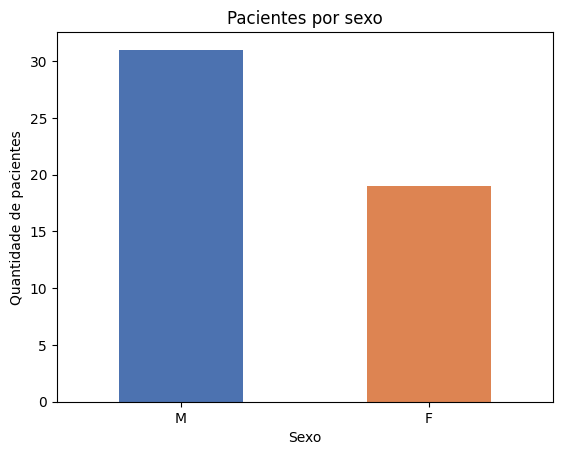

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

patients = pd.read_csv('patients.csv')
print(patients.columns.tolist())

col = next(c for c in patients.columns if c.lower() in ('gender', 'sex', 'sexo'))

contagem = patients[col].value_counts()
print(contagem)

contagem.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'][:len(contagem)])
plt.title('Pacientes por sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade de pacientes')
plt.xticks(rotation=0)
plt.show()

In [ ]:
spark.sql("SELECT * FROM patients").show()

+----------+----------+---------+------+-------------+--------------+------------+-----------------+------------------+----------------+--------------------+
|patient_id|first_name|last_name|gender|date_of_birth|contact_number|     address|registration_date|insurance_provider|insurance_number|               email|
+----------+----------+---------+------+-------------+--------------+------------+-----------------+------------------+----------------+--------------------+
|      P001|     David| Williams|     F|   1955-06-04|    6939585183| 789 Pine Rd|       2022-06-23|      WellnessCorp|       INS840674|david.williams@ma...|
|      P002|     Emily|    Smith|     F|   1984-10-12|    8228188767|321 Maple Dr|       2022-01-15|       PulseSecure|       INS354079|emily.smith@mail.com|
|      P003|     Laura|    Jones|     M|   1977-08-21|    8397029847|321 Maple Dr|       2022-02-07|       PulseSecure|       INS650929|laura.jones@mail.com|
|      P004|   Michael|  Johnson|     F|   1981-02-2

Custo total: 551249.85
Custo médio: 2756.25
                quantidade      total    media
treatment_type                                
Chemotherapy            49  128855.68  2629.71
MRI                     36  116098.16  3224.95
X-Ray                   41  110653.67  2698.87
Physiotherapy           36   99418.10  2761.61
ECG                     38   96224.24  2532.22


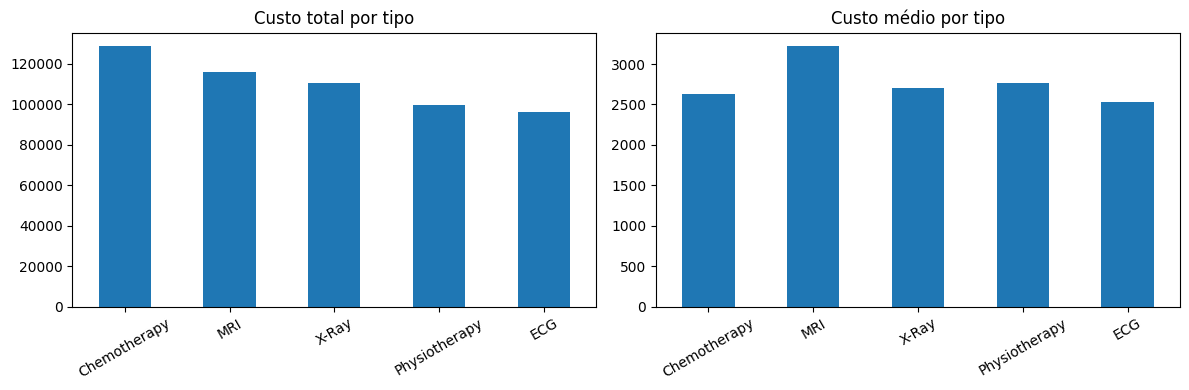

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

t = pd.read_csv('treatments.csv')

print('Custo total:', round(t['cost'].sum(), 2))
print('Custo médio:', round(t['cost'].mean(), 2))

resumo = (t.groupby('treatment_type')['cost']
            .agg(quantidade='count', total='sum', media='mean')
            .round(2)
            .sort_values('total', ascending=False))
print(resumo)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
resumo['total'].plot(kind='bar', ax=axs[0], title='Custo total por tipo')
resumo['media'].plot(kind='bar', ax=axs[1], title='Custo médio por tipo')
for ax in axs:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
import duckdb
duckdb.sql("""
    SELECT p.*, t.treatment_type, t.cost
    FROM 'treatments.csv' t
    JOIN 'appointments.csv' a ON t.appointment_id = a.appointment_id
    JOIN 'patients.csv' p ON a.patient_id = p.patient_id
    LIMIT 10
""").show()

┌────────────┬────────────┬───────────┬─────────┬───────────────┬────────────────┬──────────────┬───────────────────┬────────────────────┬──────────────────┬─────────────────────────┬────────────────┬─────────┐
│ patient_id │ first_name │ last_name │ gender  │ date_of_birth │ contact_number │   address    │ registration_date │ insurance_provider │ insurance_number │          email          │ treatment_type │  cost   │
│  varchar   │  varchar   │  varchar  │ varchar │     date      │     int64      │   varchar    │       date        │      varchar       │     varchar      │         varchar         │    varchar     │ double  │
├────────────┼────────────┼───────────┼─────────┼───────────────┼────────────────┼──────────────┼───────────────────┼────────────────────┼──────────────────┼─────────────────────────┼────────────────┼─────────┤
│ P034       │ Alex       │ Smith     │ F       │ 1950-01-26    │     8374657733 │ 321 Maple Dr │ 2023-06-18        │ WellnessCorp       │ INS653880        

                pacientes  tratamentos
treatment_type                        
Chemotherapy           32           49
ECG                    31           38
X-Ray                  28           41
Physiotherapy          23           36
MRI                    22           36


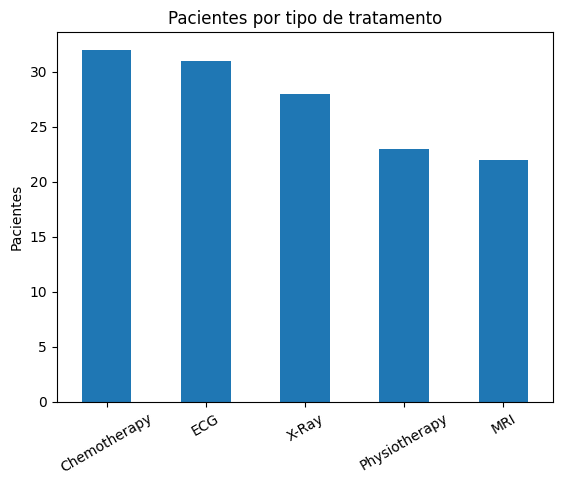

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

treatments = pd.read_csv('treatments.csv')
appointments = pd.read_csv('appointments.csv')

base = treatments.merge(appointments[['appointment_id', 'patient_id']],
                        on='appointment_id', how='left')

resultado = (base.groupby('treatment_type')
                 .agg(pacientes=('patient_id', 'nunique'),
                      tratamentos=('treatment_id', 'count'))
                 .sort_values('pacientes', ascending=False))
print(resultado)

resultado['pacientes'].plot(kind='bar', title='Pacientes por tipo de tratamento')
plt.xlabel('')
plt.ylabel('Pacientes')
plt.xticks(rotation=30)
plt.show()

(10, 8)


,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com
5,D006,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com
6,D007,Robert,Davis,Oncology,8217493115,26,Westside Clinic,dr.robert.davis@hospital.com
7,D008,Linda,Brown,Dermatology,9069162601,5,Westside Clinic,dr.linda.brown@hospital.com
8,D009,Sarah,Smith,Pediatrics,7387087517,26,Central Hospital,dr.sarah.smith@hospital.com
9,D010,Linda,Wilson,Oncology,6176383634,21,Eastside Clinic,dr.linda.wilson@hospital.com


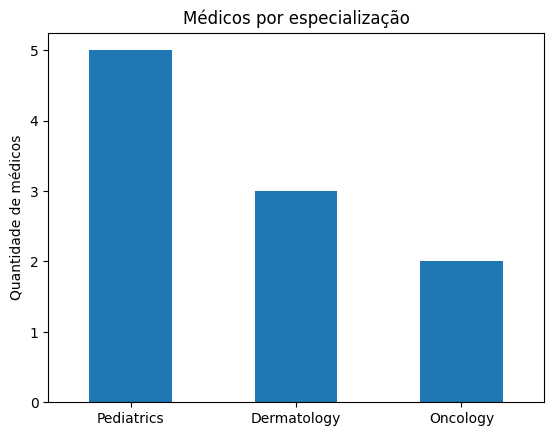

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

doctors = pd.read_csv('doctors.csv')
pd.set_option('display.max_rows', None)

print(doctors.shape)
display(doctors)

doctors['specialization'].value_counts().plot(kind='bar', title='Médicos por especialização')
plt.xlabel('')
plt.ylabel('Quantidade de médicos')
plt.xticks(rotation=0)
plt.show()